# 🔧 Data Processing Pipeline in ML
**Домашнє завдання | Data Science Club**

Датасет: **Adult Census Income** — [Kaggle](https://www.kaggle.com/datasets/uciml/adult-census-income)  
Завдання: побудувати повний ML-пайплайн від сирих даних до оціненої моделі.

---
**Як здавати:**
1. Створи публічний репозиторій на GitHub
2. Запусти ноутбук повністю (`Kernel → Restart and Run All`) — він має виконатися без помилок
3. Запушни і надішли посилання мені в приват

## 0. Імпорти та `EvaluateModel`

Запусти цю клітинку першою — тут визначено клас `EvaluateModel`, який ти **маєш використовувати** для оцінки всіх варіантів моделі у розділі 5.

Додай сюди всі потрібні імпорти.

In [100]:
!pip install pandas numpy matplotlib seaborn scikit-learn imblearn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE


class EvaluateModel:
    """
    Клас для стандартизованої оцінки RandomForestClassifier.

    Використання:
        evaluator = EvaluateModel(label="Baseline")
        evaluator.fit(X_train, y_train)
        evaluator.evaluate(X_test, y_test)

    Після виклику evaluate() результати зберігаються у словнику evaluator.results.
    Для порівняння кількох варіантів: EvaluateModel.compare([e1, e2, e3])
    """

    def __init__(self, label: str = "Model", n_estimators: int = 100, random_state: int = 42):
        self.label = label
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=random_state
        )
        self.results = {}

    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        return self

    def evaluate(self, X_test, y_test, verbose: bool = True):
        y_pred = self.model.predict(X_test)

        self.results = {
            "label":     self.label,
            "accuracy":  accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall":    recall_score(y_test, y_pred, zero_division=0),
            "f1":        f1_score(y_test, y_pred, zero_division=0),
        }

        if verbose:
            print(f"\n{'='*45}")
            print(f"  {self.label}")
            print(f"{'='*45}")
            print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

            fig, ax = plt.subplots(figsize=(4, 3))
            ConfusionMatrixDisplay.from_predictions(
                y_test, y_pred,
                display_labels=["<=50K", ">50K"],
                ax=ax, colorbar=False
            )
            ax.set_title(self.label)
            plt.tight_layout()
            plt.show()

        return self.results

    @staticmethod
    def compare(evaluators: list):
        """Зведена таблиця метрик для списку EvaluateModel."""
        rows = [e.results for e in evaluators if e.results]
        df = pd.DataFrame(rows).set_index("label").round(4)

        print("\n📊 Порівняння варіантів:")
        display(df)

        df[["accuracy", "precision", "recall", "f1"]].plot(
            kind="bar", figsize=(9, 4), ylim=(0, 1),
            title="Порівняння метрик", rot=0
        )
        plt.tight_layout()
        plt.show()
        return df

---
## 1. Завантаження даних

Завантаж датасет `adult.csv` та виведи базову інформацію

In [102]:
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


---
## 2. Exploratory Data Analysis (EDA)

Дослідж датасет **до будь-якої обробки**. Що варто розглянути:
- розподіл цільової змінної `income` і співвідношення класів
- розподіл числових ознак
- огляд категоріальних ознак
- пропущені значення
- взаємозв'язки між ознаками

Після аналізу **обов'язково** додай markdown-клітинку з ключовими спостереженнями

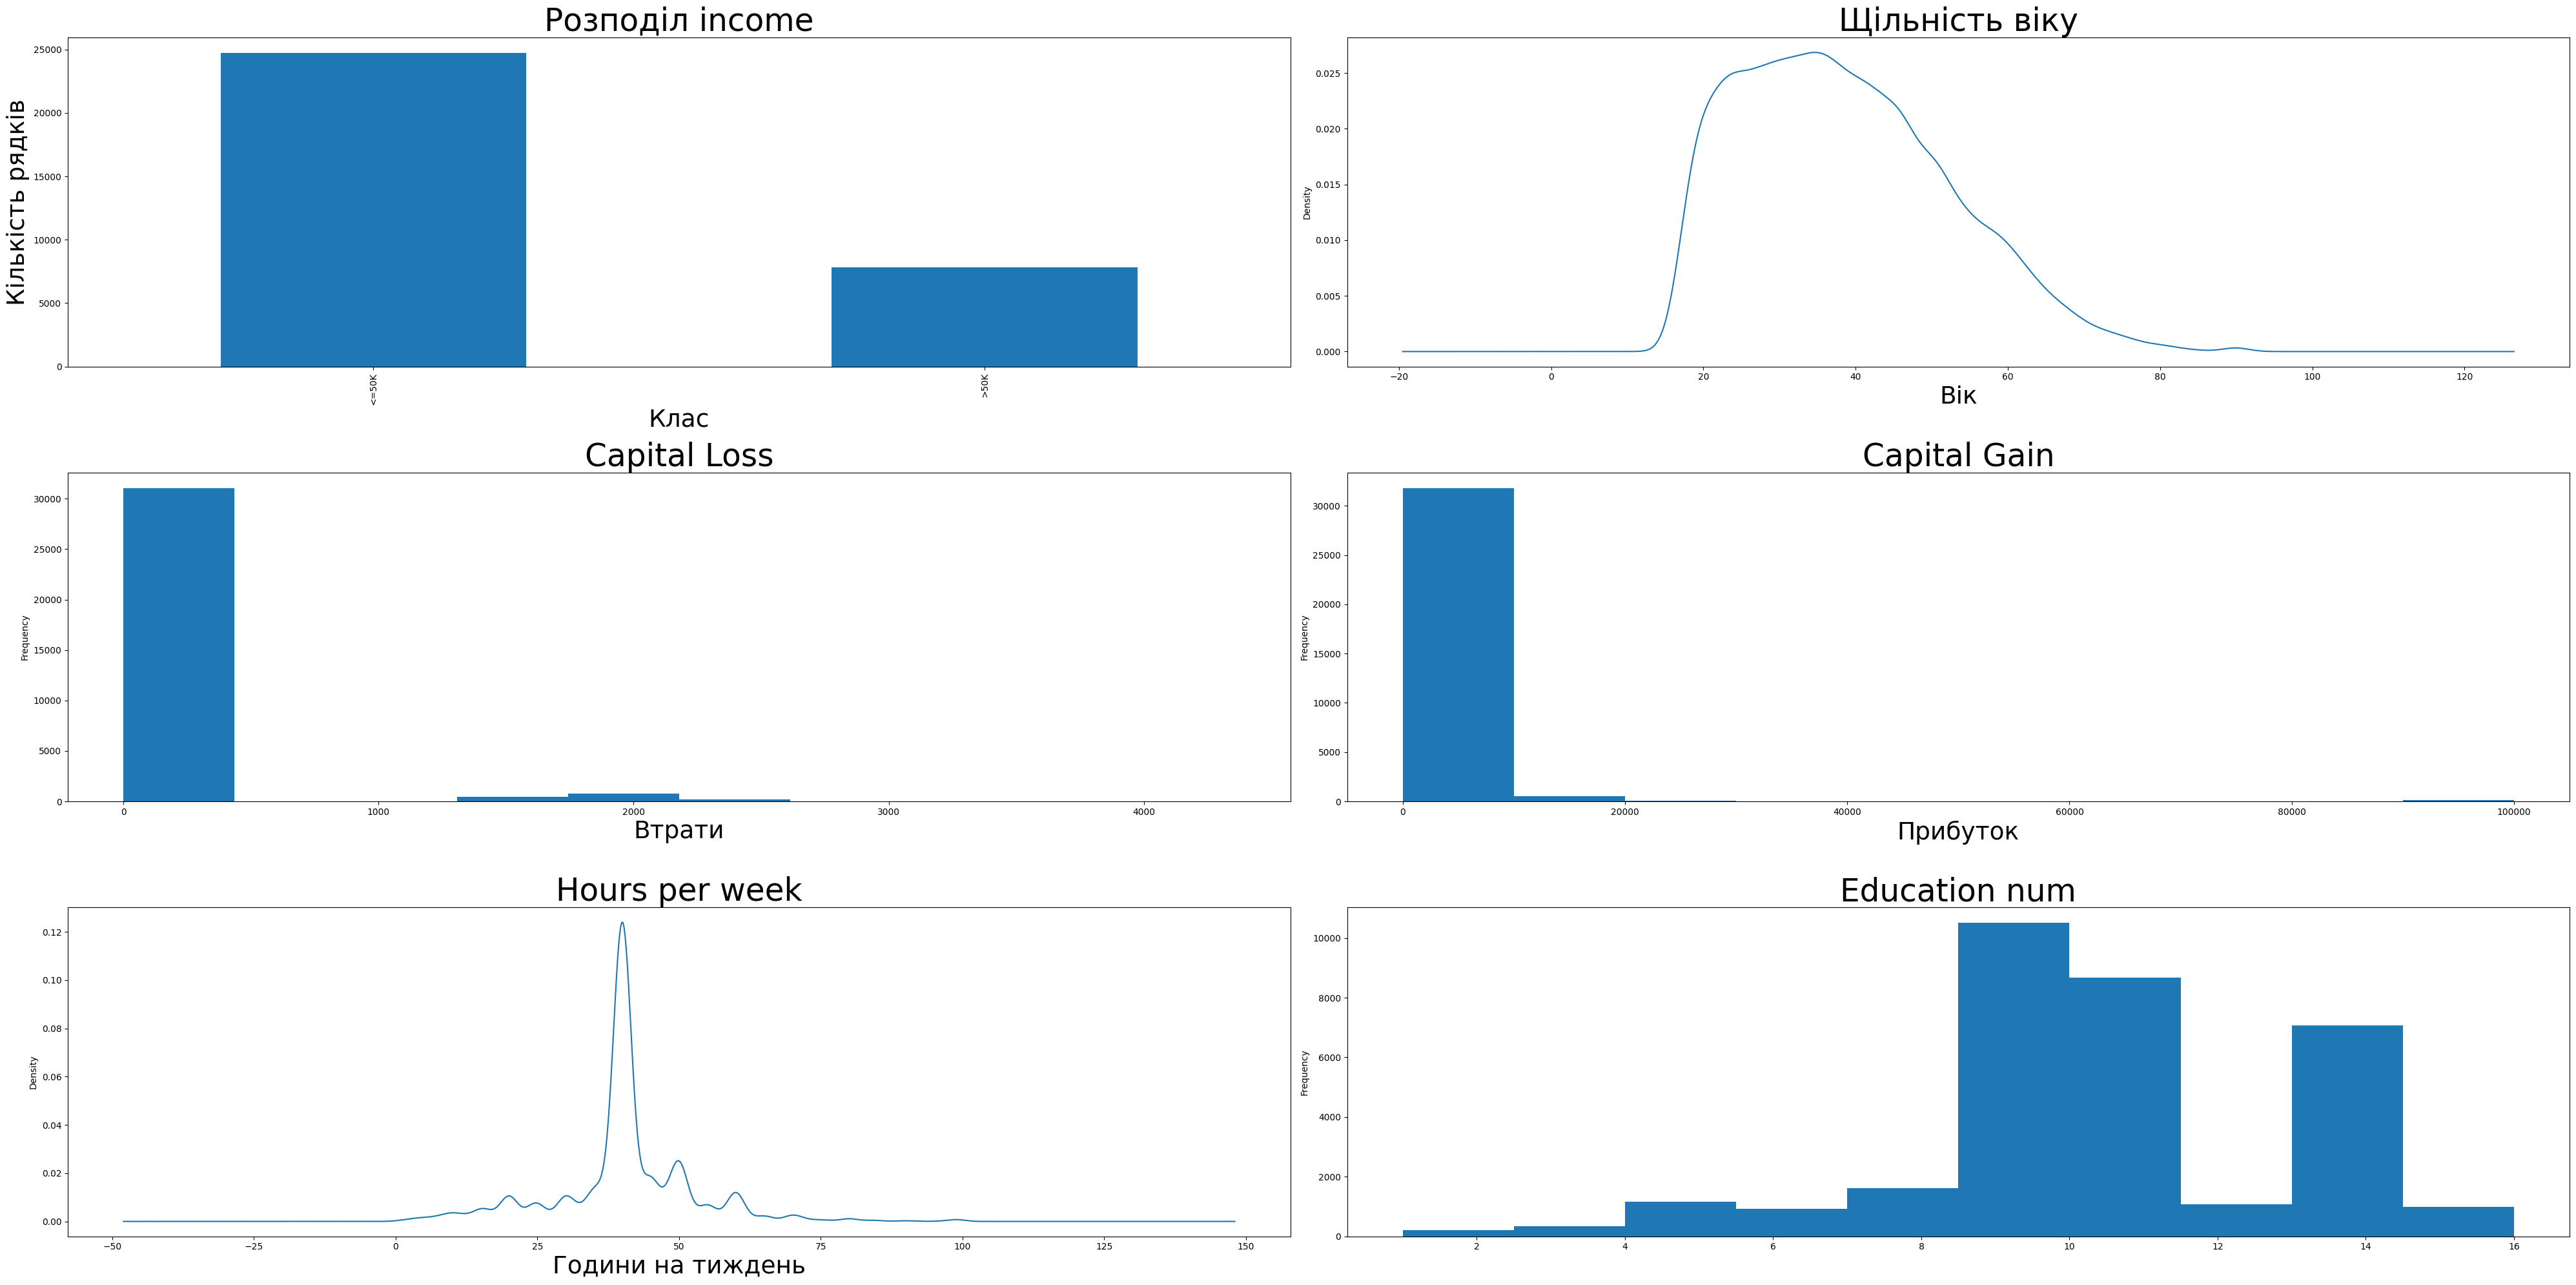

Mean age: 38.58164675532078
Mean hours per week: 40.437455852092995


In [103]:
# Розподіл income та розподіл числових ознак

fig, axes = plt.subplots(3, 2, figsize=(40, 20))

plots = [
    ('income', 'bar', 'Розподіл income', 'Клас', 'Кількість рядків'),
    ('age', 'kde', 'Щільність віку', 'Вік', None),
    ('capital.loss', 'hist', 'Capital Loss', 'Втрати', None),
    ('capital.gain', 'hist', 'Capital Gain', 'Прибуток', None),
    ('hours.per.week', 'kde', 'Hours per week', 'Години на тиждень', None),
    ('education.num', 'hist', 'Education num', None, None)
]

for ax, (col, kind, title, xlabel, ylabel) in zip(axes.ravel(), plots):
    if col == 'income':
        df[col].value_counts().plot(kind=kind, ax=ax)
    else:
        df[col].plot(kind=kind, ax=ax)

    ax.set_title(title, fontsize=35)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=27)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=27)

plt.tight_layout()
plt.show()

print('Mean age:', df['age'].mean())
print('Mean hours per week:', df['hours.per.week'].mean())

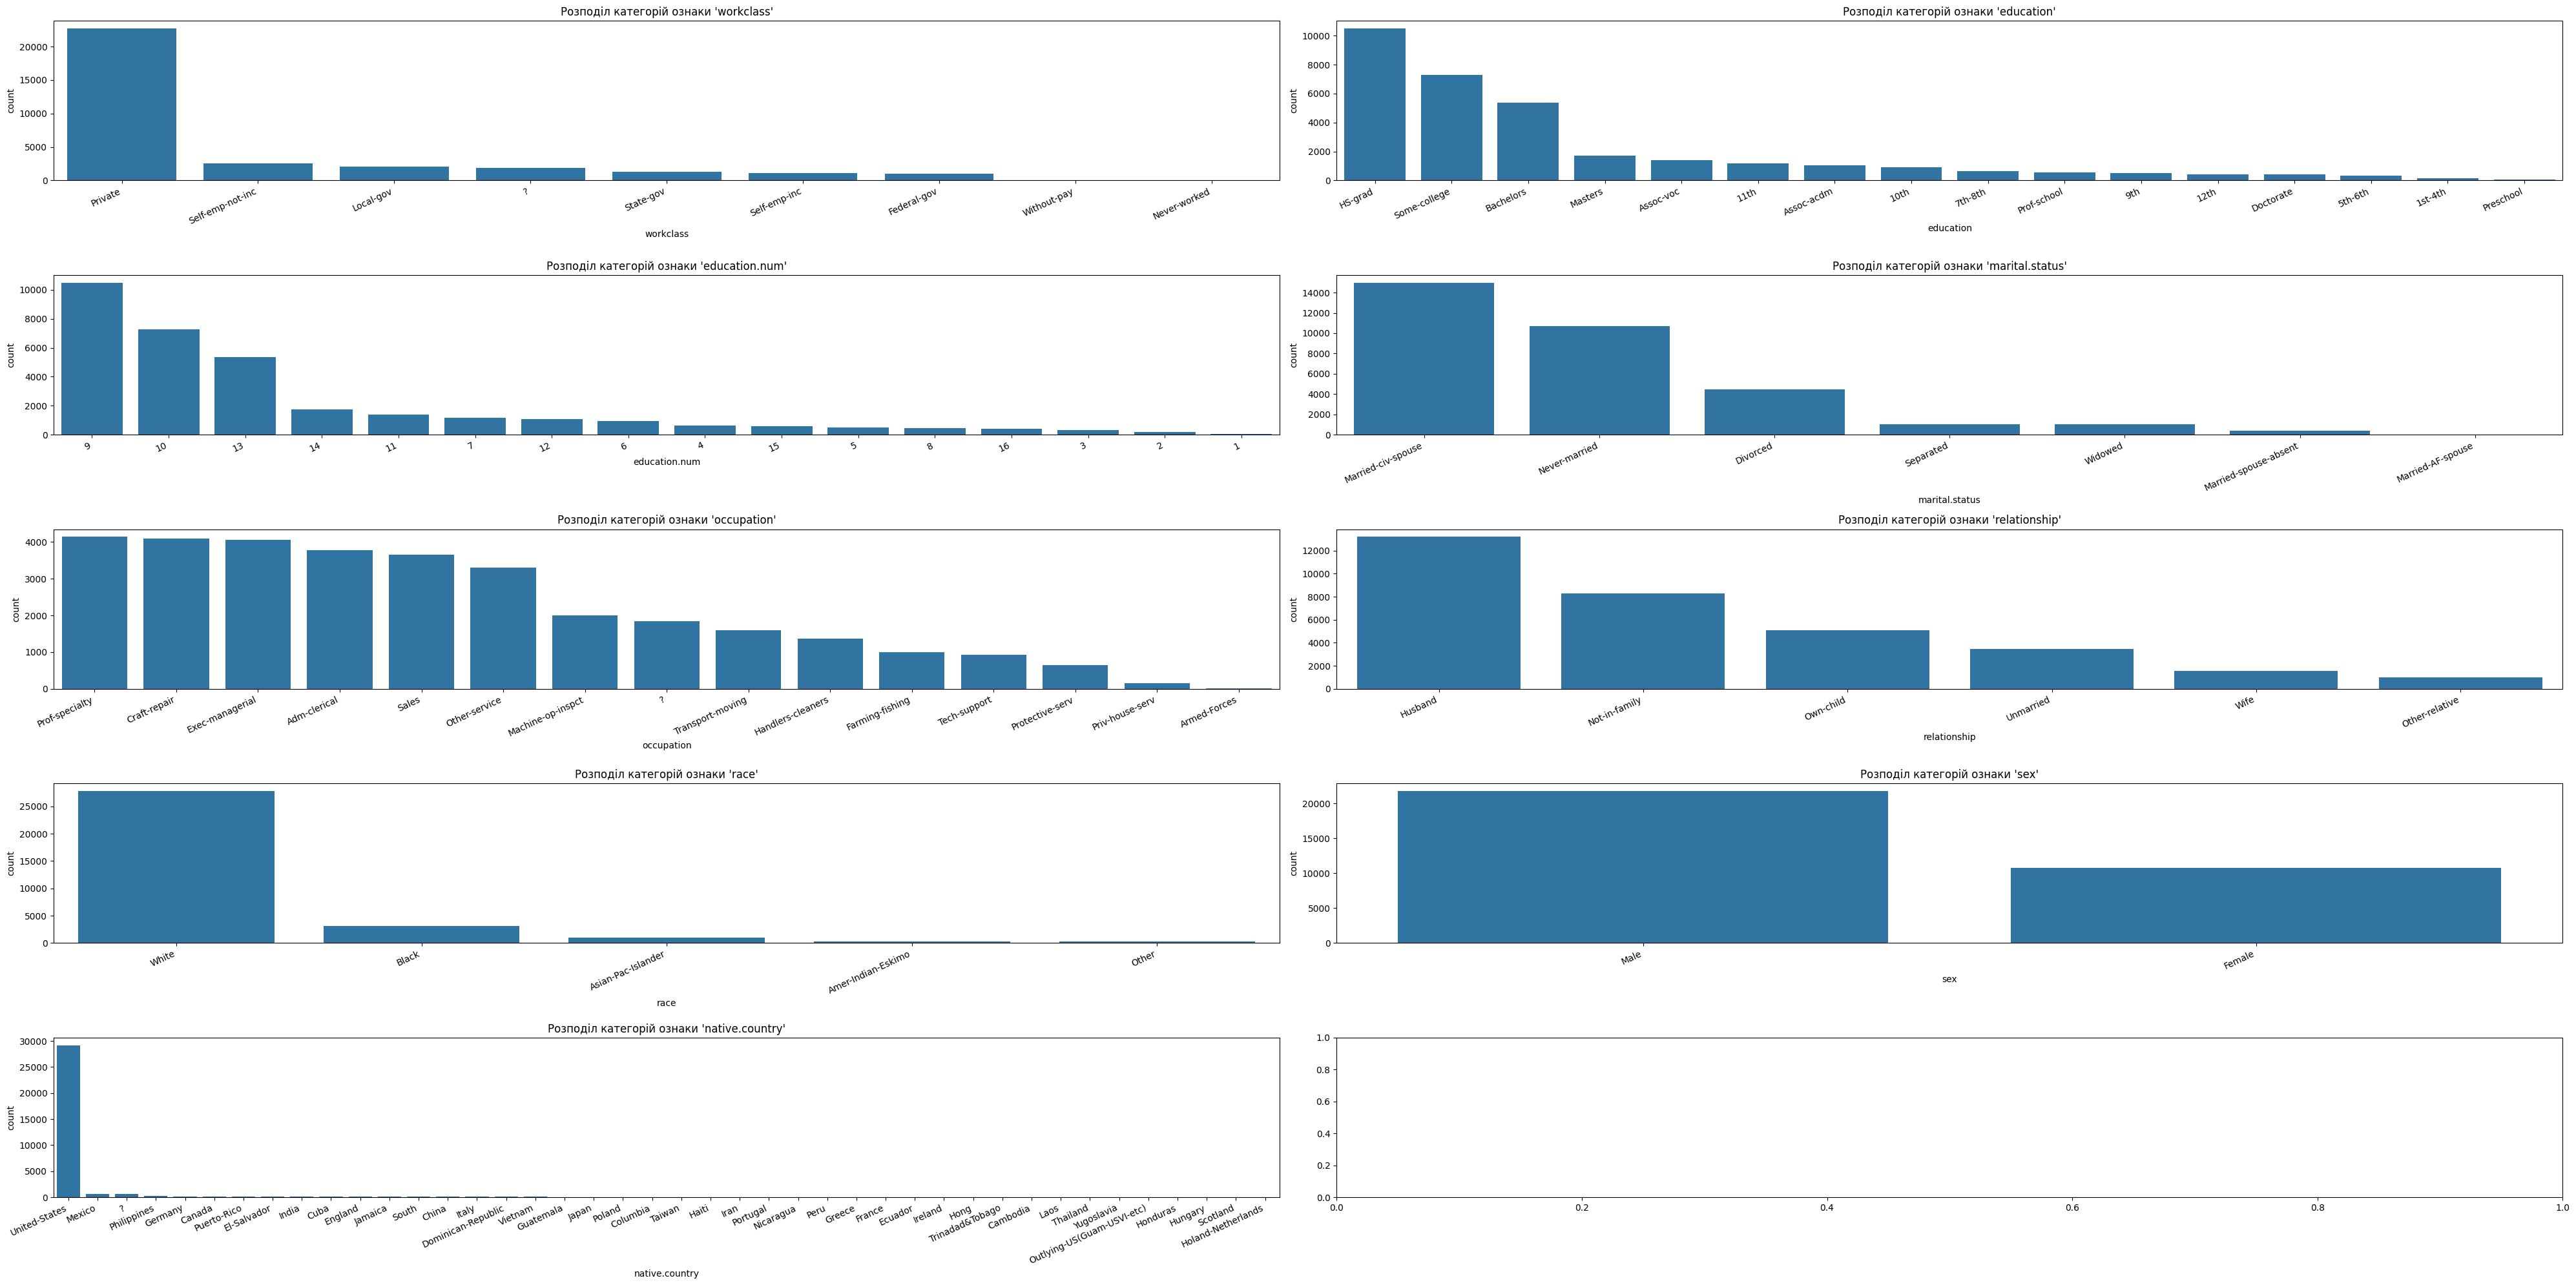

In [104]:
# Огляд категоріальних ознак

cols = ['workclass', 'education', 'education.num', 
       'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

fig, axes = plt.subplots(5, 2, figsize=(40, 20))

for i, col in enumerate(cols):
    ax = axes[i//2][i%2]
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axes[i//2][i%2])
    ax.set_title(f"Розподіл категорій ознаки '{col}'")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
plt.show()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


<Axes: >

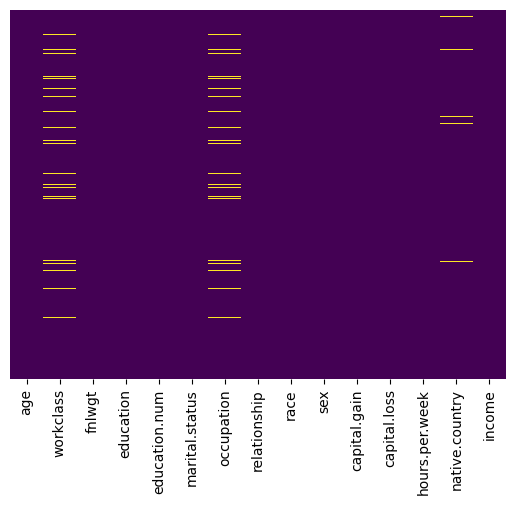

In [105]:
# Пропущені значення
print((df == '?').sum())

sns.heatmap(df == '?', cbar=False, yticklabels=False, cmap='viridis')

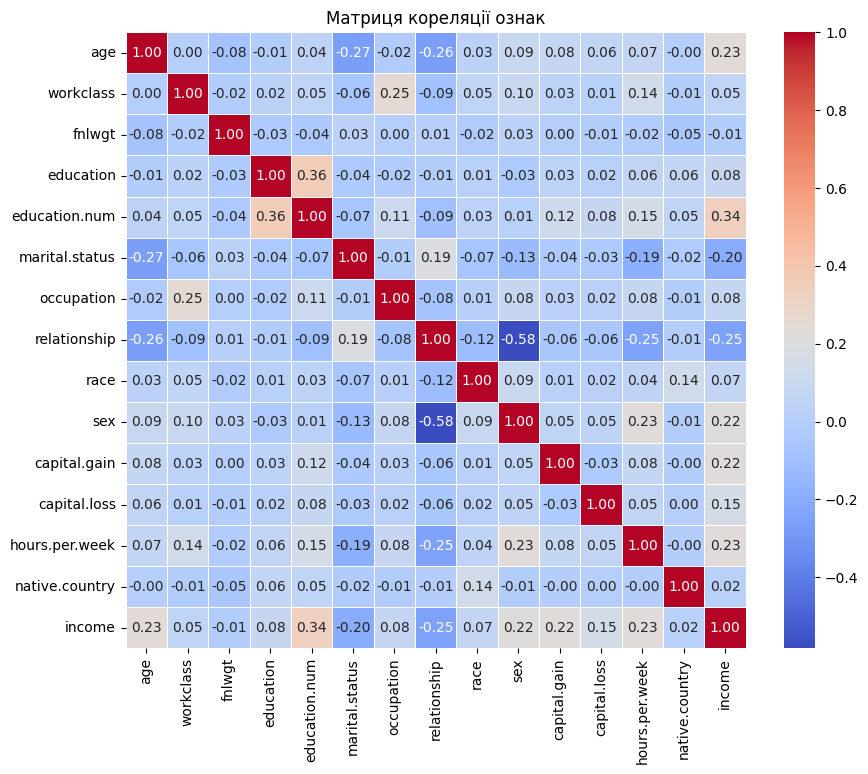

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,0,77053,11,9,6,0,1,4,0,0,4356,40,39,0
1,82,4,132870,11,9,6,4,1,4,0,0,4356,18,39,0
2,66,0,186061,15,10,6,0,4,2,0,0,4356,40,39,0
3,54,4,140359,5,4,0,7,4,4,0,0,3900,40,39,0
4,41,4,264663,15,10,5,10,3,4,0,0,3900,40,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,4,310152,15,10,4,11,1,4,1,0,0,40,39,0
32557,27,4,257302,7,12,2,13,5,4,0,0,0,38,39,0
32558,40,4,154374,11,9,2,7,0,4,1,0,0,40,39,1
32559,58,4,151910,11,9,6,1,4,4,0,0,0,40,39,0


In [106]:
# Взаємозв'язки між ознаками

df_temp = df.copy()

for col in df_temp.select_dtypes(include='object').columns:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col])

corr_matrix = df_temp.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Матриця кореляції ознак')
plt.show()

df_temp

**Висновки EDA:**  

#### Основні спостереження:
- ##### Розподіл income та розподіл числових ознак
    - У нашому датасеті є дизбаланс класів: міток <=50K набагато більше ніж >50K
    - Модою capital.gain і capital.loss є 0
    - Найбільша кількість зразків з датасету мають освіту HS-grad
    - Середній вік зразків приблизно дорівнює 40 років
    - Середня кількість пропрацьованих годин в тиждень приблизно дорівнює 40, тобто 8 годин в будній день.

- ##### Огляд категоріальних ознак
    - Дисбаланс за статтю та расою
    - Абсолютна більшість людей походить із США
    - Найпопулярніші ролі — "Чоловік" (Husband) та "Одружений" (Married-civ-spouse)
    - Понад 70% працюють у категорії Private
    - Рівень освіти: Найпоширеніший рівень - випускник школи
    - Професії розподілені досить рівномірно: найбільші групи - це фахівці високого рівня (Prof-specialty), керівники (Exec-managerial) та ремісники(Craft-repair)

- ##### Пропущені значення
    - У колонках workclass, occupation та native-country є знак "?"
    - Категорії на кшталт Armed-Forces (військові) або Never-worked настільки малі, що вони не дадуть моделі достатньо інформації, тому їх варто об'єднати в одну категорію "Other"

- ##### Взаємозв'язки між ознаками
    - Найбільше на фічу income впливають education.num (0.34 позитивний коефіцієнт)
    - hours.per.week (0.23): Позитивний зв'язок. Хто працює більше годин, той зазвичай більше заробляє.
    - Age (0.23) - чим більший вік, тим більші зарплати
    - education та education.num дуже сильно корелюють, тому один з них можна видалити.
    - Sex та relationship також дуже сильно корелюють, тому їх можна об'єднати
    - Ознаки fnlwgt та native.country майже не корелюють з вихідною ознакою, тому їх можна видалити.


---
## 6. Навчання та оцінка моделі

Використовуй **виключно** клас `EvaluateModel` з першої клітинки

Натренуй і порівняй **3 варіанти**:
- **Baseline** — мінімальна обробка
- **Full Pipeline** — повний пайплайн з розділів 3–4
- **Full Pipeline + SMOTE** — з балансуванням класів


  Baseline
              precision    recall  f1-score   support

       <=50K       0.86      0.91      0.88      4976
        >50K       0.64      0.53      0.58      1537

    accuracy                           0.82      6513
   macro avg       0.75      0.72      0.73      6513
weighted avg       0.81      0.82      0.81      6513



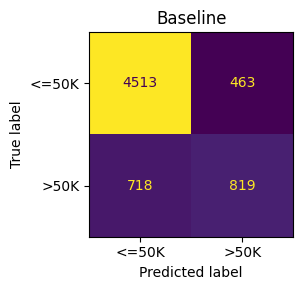

{'label': 'Baseline',
 'accuracy': 0.8186703516044833,
 'precision': 0.6388455538221529,
 'recall': 0.5328562134027326,
 'f1': 0.5810571124512238}

In [26]:
raw_df = pd.read_csv("adult.csv", na_values="?", skipinitialspace=True)

X = raw_df.drop(columns=['income', 'fnlwgt', 'education.num'])
y = LabelEncoder().fit_transform(raw_df['income'])

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = X.select_dtypes(exclude='number').columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(), cat_cols)
])


X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

e_baseline = EvaluateModel(label="Baseline")
e_baseline.fit(X_train_proc, y_train)
e_baseline.evaluate(X_test_proc, y_test)



  Full Pipeline
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4533
        >50K       0.71      0.61      0.66      1500

    accuracy                           0.84      6033
   macro avg       0.80      0.76      0.78      6033
weighted avg       0.84      0.84      0.84      6033



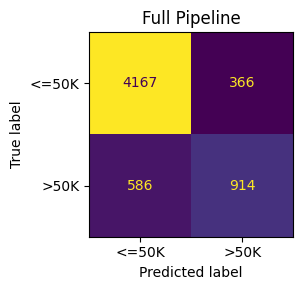

{'label': 'Full Pipeline',
 'accuracy': 0.8422012265871043,
 'precision': 0.7140625,
 'recall': 0.6093333333333333,
 'f1': 0.6575539568345323}

In [ ]:
def prepare_adult_data(df, test_size=0.2, random_state=42):
    df = df.dropna()

    df["capital.net"] = df["capital.gain"] - df["capital.loss"]

    df["age.group"] = pd.cut(
        df["age"],
        bins=[17, 25, 40, 60, 100],
        labels=["young", "adult", "middle", "senior"]
    )

    df["native.country"] = df["native.country"].apply(
        lambda x: "US" if x == "United-States" else "Other"
    )

    df["hours.group"] = pd.cut(
        df["hours.per.week"],
        bins=[0, 25, 40, 60, 100],
        labels=["part_time", "normal", "extra", "workaholic"]
    )

    df["age_hours"] = df["age"] * df["hours.per.week"]

    df["capital.gain"] = np.log1p(df["capital.gain"])
    df["capital.loss"] = np.log1p(df["capital.loss"])

    df = df.drop(columns=["fnlwgt"])

    df["income"] = df["income"].apply(lambda x: 1 if ">50K" in x else 0)

    df = pd.get_dummies(df, drop_first=True)

    X = df.drop("income", axis=1)
    y = df["income"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    scaler = StandardScaler()

    num_cols = [
        "age",
        "education.num",
        "hours.per.week"
    ]

    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    return X_train, X_test, y_train, y_test, scaler

e_pipeline = EvaluateModel(label='Full Pipeline')
e_pipeline.fit(X_train, y_train)
e_pipeline.evaluate(X_test, y_test)


  Full Pipeline + SMOTE
              precision    recall  f1-score   support

       <=50K       0.89      0.89      0.89      4533
        >50K       0.67      0.67      0.67      1500

    accuracy                           0.84      6033
   macro avg       0.78      0.78      0.78      6033
weighted avg       0.84      0.84      0.84      6033



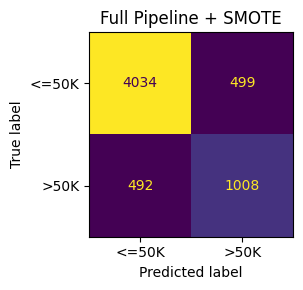

{'label': 'Full Pipeline + SMOTE',
 'accuracy': 0.8357367810376264,
 'precision': 0.6688785666887856,
 'recall': 0.672,
 'f1': 0.6704356501496508}

In [25]:
df = pd.read_csv("adult.csv", na_values="?", skipinitialspace=True)

df = df.dropna()

df["capital.net"] = df["capital.gain"] - df["capital.loss"]

df["age.group"] = pd.cut(
    df["age"],
    bins=[17, 25, 40, 60, 100],
    labels=["young","adult","middle","senior"]
)

df["native.country"] = df["native.country"].apply(
    lambda x: "US" if x == "United-States" else "Other"
)

df = df.drop(columns=["fnlwgt"])

df["income"] = df["income"].apply(lambda x: 1 if ">50K" in x else 0)

df = pd.get_dummies(df, drop_first=True)

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

num_cols = [
    "age","education.num","hours.per.week",
]

df["capital.gain"] = np.log1p(df["capital.gain"])
df["capital.loss"] = np.log1p(df["capital.loss"])

df["hours.group"] = pd.cut(
    df["hours.per.week"],
    bins=[0, 25, 40, 60, 100],
    labels=["part_time","normal","extra","workaholic"]
)

df["age_hours"] = df["age"] * df["hours.per.week"]


X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

e_smote = EvaluateModel(label="Full Pipeline + SMOTE")
e_smote.fit(X_train_bal, y_train_bal)
e_smote.evaluate(X_test, y_test)



📊 Порівняння варіантів:


,accuracy,precision,recall,f1
label,,,,
Baseline,0.8187,0.6388,0.5329,0.5811
Full Pipeline,0.8422,0.7141,0.6093,0.6576
Full Pipeline + SMOTE,0.8357,0.6689,0.6720,0.6704


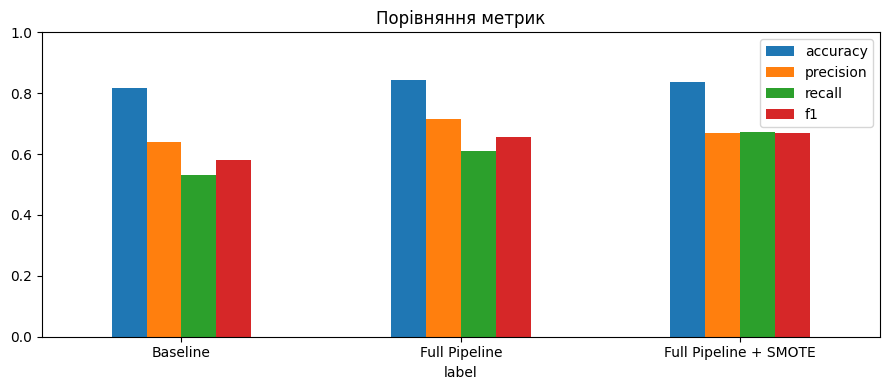

,accuracy,precision,recall,f1
label,,,,
Baseline,0.8187,0.6388,0.5329,0.5811
Full Pipeline,0.8422,0.7141,0.6093,0.6576
Full Pipeline + SMOTE,0.8357,0.6689,0.6720,0.6704


In [19]:
EvaluateModel.compare([e_baseline, e_pipeline, e_smote])

---
## 7. Висновки

1. Найкращий F1 показав Full Pipeline без SMOTE. SMOTE зменшує accuracy, проте збільшує recall. Accuracy зменшується через фікс дизбалансу класів, recall збільшується через те що ми покриваємо більшу кількість зразків конкретної категорії.
2. Найбільше на якість моделі вплинув фіче-інжинірінг та OneHot і OrderedEncoder. Найменше - скейлінг, оскільки RandomForest не чутливий до масштабу.
3. Я б провів кращий EDA, щоб краще дізнатися природу даних в датасеті./